# Workshop figures (CCAI) — the ensemble spread is under-dispersed, escalating with flow

Frozen ensemble quantities only: the ensemble mean $\hat{\mu}$ and the between-member spread $\hat{\sigma}^2_e$ (sample variance across $M{=}10$ deterministic members, $1/(M{-}1)$ normalization; split unmodified). $\hat{\sigma}^2_e$ **is read as a lower bound on** the epistemic uncertainty a well-specified ensemble should express — never *is* epistemic uncertainty.

**Claim.** The model is skilled (the mean is good), yet $\hat{\sigma}^2_e$ is **pervasively under-dispersed, escalating with flow magnitude**. The spread *does* widen with flow — by $8.5\times$ across the deciles — but the residual widens by $24.6\times$, so the gap opens from $\approx2\times$ to $5.8\times$. It does not widen *enough*; it never fails to widen. Error common to all members (*common-mode*) is invisible to a between-member spread. Aleatoric uncertainty is handled elsewhere [Klotz, Kraft]; there is **no variance head** here — members are deterministic point predictors.

**Shift is the test, not the mechanism** (2026-08-06). The mechanism is flow magnitude and training-support density: the failure is fully present in-distribution, and the top flow decile is where basin-days enter the sparsely-constrained upper tail of training (62% above the basin's train p95, but only 0.69% above its train maximum). The 2021 event windows are a **held-out probe** confirming the same mechanism at greater magnitude — not a separate regime. Separating the two blocks is what forces this reading: the heat dome is *better* calibrated than in-distribution at every decile, and the large pooled OOD number comes from the AR flood alone. See the block-separation diagnostic below.

Figure set: **Overleaf Fig 1** = undersize factor by flow decile; **Overleaf Fig 2** = error after removal on the OOD windows. The event hydrographs below are not used in the workshop paper.

In [1]:
# Frozen ensemble grids + shared plotting style (CCAI, NeurIPS single-column)
import sys, pathlib
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import spearmanr

# ---- locate project root (dir holding src/config.py), independent of kernel cwd ----
# Re-running this cell self-heals a stale kernel after the source dir moves:
# it finds the current tree and drops any cached `src.*` so the import rebinds.
_root = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
              if (p / "src" / "config.py").exists()), None)
if _root is None:
    raise RuntimeError(f"project root not found from cwd={pathlib.Path.cwd()}; "
                       "launch Jupyter inside the repo (or run this cell from within it).")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
for _m in [m for m in list(sys.modules) if m == "src" or m.startswith("src.")]:
    del sys.modules[_m]
from src.config import OUTPUT_DATA_DIR
print(f"project root: {_root}")

# ============================ SIZING SYSTEM ============================
# Figures render at S x their in-paper size. In LaTeX use:
#     \includegraphics[width=\columnwidth]{fig.pdf}
# S cancels under width=..., so ONLY (aspect ratio) and (font:width ratio)
# reach the page -- both are fixed here. All widths are uniform (=FIG_W*S)
# so the three figures are visually consistent; heights are minimized.
S      = 1.8            # source-render scale ("big"); cancels at width=\columnwidth
FIG_W  = 5.5           # intended in-paper width (NeurIPS/CCAI single-column text width, in)
def figsize(ratio):    # ratio = width:height ; larger ratio => shorter (less vertical space)
    return (FIG_W*S, (FIG_W/ratio)*S)
def off(x, y):  return (x*S, y*S)     # scale offset-point annotation offsets
def sz(area):   return area*S*S       # scale scatter marker AREA (points^2) ~ linear in S

# absolute type/line sizes (pt), all x S so the font:width ratio is invariant
FS = dict(title=10*S, sub=9*S, lab=9*S, tick=8*S, leg=8*S, ann=8*S, emph=10*S)
LW = dict(thin=0.6*S, mu=1.4*S, obs=1.9*S, ref=1.7*S, curve=2.4*S)

# ---- brand-neutral, colorblind-safe (Okabe-Ito), assigned by JOB ----
PALETTE = dict(
    obs    = "#111111",   # observations / realized error (truth)
    mu     = "#8A8A8A",   # ensemble mean mu-hat (recessive reference)
    ens    = "#D55E00",   # between-member spread sigma_e (the signal under test)
    indist = "#0072B2",   # in-distribution / calibrated regime
    ref    = "#555555",   # nominal / best-possible / neutral references
    random = "#AFAFAF",   # no-skill baseline
)
mpl.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 8.5*S,
    "axes.titlesize": FS["title"], "axes.titleweight": "bold", "axes.titlepad": 6*S,
    "axes.labelsize": FS["lab"], "axes.labelpad": 3*S,
    "xtick.labelsize": FS["tick"], "ytick.labelsize": FS["tick"], "legend.fontsize": FS["leg"],
    "axes.linewidth": 0.9*S, "axes.edgecolor": "#444444",
    "axes.grid": True, "grid.color": "#666666", "grid.alpha": 0.28,
    "grid.linestyle": ":", "grid.linewidth": 0.7*S,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#444444", "ytick.color": "#444444",
    "xtick.major.size": 3*S, "ytick.major.size": 3*S,
    "xtick.major.width": 0.8*S, "ytick.major.width": 0.8*S,
    "legend.frameon": False, "mathtext.fontset": "dejavusans",
})
SIG = r"$\hat{\sigma}^2_e$"; MU = r"$\hat{\mu}$"
FIG_OUT = _root/"figures"  # exported PNGs land here, mirroring the Overleaf figures/ dir
FIG_OUT.mkdir(exist_ok=True)

# opaque legend box: panel (b)'s curves and Fig 2's whiskers run behind the legend,
# and rcParams sets frameon=False globally, so text on bare curves was unreadable
LEG = dict(frameon=True, facecolor="white", edgecolor="#CCCCCC", framealpha=.95,
           borderpad=.45, labelspacing=.35, handletextpad=.6)

def panel(ax, letter, title, **kw):
    """Chapter-style bold, left-aligned '(x) Title' panel header."""
    kw.setdefault("fontsize", FS["sub"])
    ax.set_title(f"({letter}) {title}", loc="left", fontweight="bold", **kw)

# ---- frozen quantities (mu-hat, sigma_e^2, split unmodified) ----
R = OUTPUT_DATA_DIR/"results_MVE"; VAR = R/"variance"
idx = pd.read_csv(R/"index_dates.csv", parse_dates=["date"])
dates = pd.DatetimeIndex(idx["date"]); split = idx["split"].to_numpy()
y = np.load(R/"y_obs_mm.npy")
try: valid = np.load(R/"valid_mask.npy")
except FileNotFoundError: valid = np.load(R/"valid_mask_ald.npy")
pred = np.load(VAR/"predictive.npz")
mu, sigma_e2 = pred["mu_hat"], pred["sigma_e2"]
sig_e = np.sqrt(sigma_e2)                        # between-member spread
stations = pd.read_csv(R/"q_std.csv")["station_id"].astype(str).to_numpy()
Z = 1.96

# ---- OOD illustration windows (2021 heat dome, AR flood) ----
EVENTS = {"2021 heat dome": ("2021-06-01","2021-07-31"),
          "2021 AR flood":  ("2021-10-20","2021-12-10")}
test = (split=="test")

# Each event gets its own SPATIAL extent -- pooling both over all 269 basins dilutes the
# regional one and flatters it. Heat dome: domain-wide (forcing selection would retain
# 264/269, so restricting is pointless). AR flood: a Lower Mainland / SW-BC event, so
# basins west of -121 deg only -- a generous, purely geographic cut that conditions on
# neither the forcing nor the outcome. See the block-separation cell for the sensitivity.
from src.config import OUTPUT_STATIC_ATTR
_at = pd.read_csv(OUTPUT_STATIC_ATTR, index_col=0); _at.index = _at.index.astype(str)
lon = _at.reindex(stations)["longitude"].values
AR_WEST = (lon < -121) & np.isfinite(lon)                        # 74 basins
HD_DAYS = (dates>=pd.Timestamp("2021-06-01")) & (dates<=pd.Timestamp("2021-07-31"))
AR_DAYS = (dates>=pd.Timestamp("2021-10-20")) & (dates<=pd.Timestamp("2021-12-10"))
ood_date = HD_DAYS | AR_DAYS                                     # dates only (Fig-1 hydrographs)
# AR-window basin-days OUTSIDE the affected region are ordinary autumn conditions, so they
# stay in the in-distribution group; the two groups remain an exhaustive partition of test.
ood_cell = (HD_DAYS[:,None] & np.ones(len(stations), bool)[None,:]) | (AR_DAYS[:,None] & AR_WEST[None,:])
M_ood = (test[:,None] & ood_cell) & valid       # OOD event basin-days (test-only by construction)
M_ind = (test[:,None] & ~ood_cell) & valid      # in-distribution test basin-days
err = np.abs(y-mu); err2 = (y-mu)**2

# within-basin flow-percentile deciles (regime stratification), ranked within the TEST
# period ONLY so train/val flows never inform the binning (test-set-only figures)
pct = pd.DataFrame(np.where(test[:,None] & valid, y, np.nan)).rank(pct=True).to_numpy()
bi = np.clip(np.nan_to_num(pct)*10, 0, 9).astype(int)
tb = (test[:,None] & valid) & np.isfinite(pct)
print(f"style: source {FIG_W*S:.1f}in wide (S={S}); set width=\\columnwidth in LaTeX")
print(f"test basin-days {int(tb.sum()):,} | in-dist {int(M_ind.sum()):,} | OOD {int(M_ood.sum()):,}"
      f"  (heat dome all {len(stations)} basins; AR flood {int(AR_WEST.sum())} basins west of -121)")

project root: /Users/justingallant/src/Research-2026S/EA-LSTM-Streamflow
style: source 9.9in wide (S=1.8); set width=\columnwidth in LaTeX
test basin-days 877,729 | in-dist 857,477 | OOD 20,252  (heat dome all 269 basins; AR flood 74 basins west of -121)


## Figure 1 — Event hydrographs: the ensemble band misses the peak *(illustration)*
Observed runoff vs the ensemble mean $\hat{\mu}$, with the $\pm1.96\,\hat{\sigma}_e$ between-member band, for the two 2021 OOD events. The band is a sliver hugging the mean — it does not reach the observed peaks. These events *illustrate* the population result in Fig. 2; they are not the evidence base.

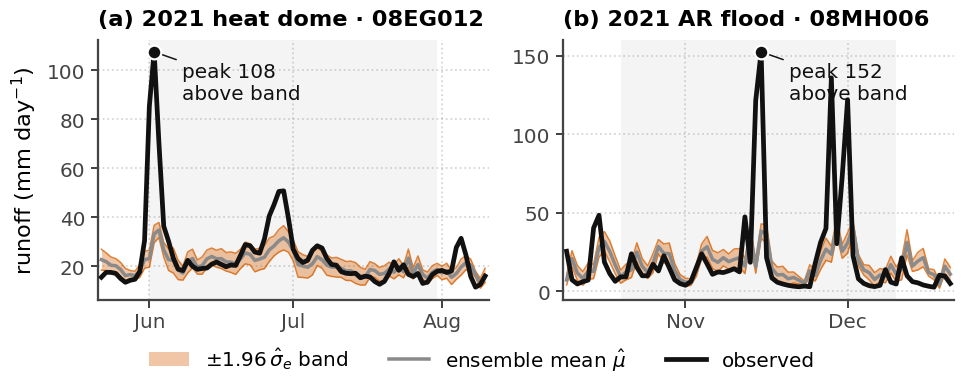

In [2]:
fig, axes = plt.subplots(1, 2, figsize=figsize(2.5))
for k,(ax,(nm,(a,b))) in enumerate(zip(axes, EVENTS.items())):
    a_ts, b_ts = pd.Timestamp(a), pd.Timestamp(b)
    w = (dates >= a_ts-pd.Timedelta(days=10)) & (dates <= b_ts+pd.Timedelta(days=10))
    wi = np.where(w)[0]; core = (dates>=a_ts)&(dates<=b_ts)
    j = int(np.nanargmax(np.nanmax(np.where(core[:,None]&valid, y, np.nan), axis=0)))
    d = dates[wi]; o = y[wi,j]; m = mu[wi,j]; sE = sig_e[wi,j]
    ax.axvspan(a_ts, b_ts, color="#000000", alpha=.045, lw=0, zorder=0)      # event window
    ax.fill_between(d, m-Z*sE, m+Z*sE, color=PALETTE["ens"], alpha=.35, lw=0, zorder=2,
                    label=r"$\pm1.96\,\hat{\sigma}_e$ band")
    ax.plot(d, m+Z*sE, color=PALETTE["ens"], lw=LW["thin"], alpha=.75, zorder=2)
    ax.plot(d, m-Z*sE, color=PALETTE["ens"], lw=LW["thin"], alpha=.75, zorder=2)
    ax.plot(d, m, color=PALETTE["mu"], lw=LW["mu"], zorder=3, label=f"ensemble mean {MU}")
    ax.plot(d, o, color=PALETTE["obs"], lw=LW["obs"], zorder=4, label="observed")
    oc = np.where(core[wi], o, np.nan); kp = int(np.nanargmax(oc))
    ax.plot(d[kp], o[kp], "o", ms=5.5*S, mfc=PALETTE["obs"], mec="white", mew=.9*S, zorder=6)
    ax.annotate(f"peak {o[kp]:.0f}\nabove band", xy=(d[kp], o[kp]),
                xytext=off(11, -4), textcoords="offset points", ha="left", va="top",
                fontsize=FS["ann"], color=PALETTE["obs"],
                arrowprops=dict(arrowstyle="-", lw=LW["thin"], color=PALETTE["obs"]))
    panel(ax, "ab"[k], f"{nm} · {stations[j]}")
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.margins(x=.01)
axes[0].set_ylabel(r"runoff (mm day$^{-1}$)")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, bbox_to_anchor=(.5, -.02), fontsize=FS["leg"])
fig.tight_layout(rect=(0, .07, 1, 1)); plt.show()

**How to read it · station selection.** Each panel shows the single basin with the **largest observed peak** inside that event window, chosen automatically across all 269 basins:

```
core = (dates >= a) & (dates <= b)                                  # the event window
j = nanargmax( nanmax( where(core & valid, y, nan), axis=0 ) )      # basin with the biggest event peak
```

That gives the heat dome → **08EG012** (108 mm day⁻¹) and the AR flood → **08MH006** (152 mm day⁻¹); the plotted window is padded ±10 days so the rise and recession are visible.

- The $\pm1.96\,\hat{\sigma}_e$ band is a **sliver on $\hat{\mu}$** and never reaches the observed peak — the between-member spread does not widen where the model most under-predicts.
- This is **selection on the outcome** (the observed peak), so Fig. 1 is an **illustration, not evidence**, and not representative — the population result in Fig. 2 is the evidence base. Selecting on the *physical event magnitude* (not on model error or on $\hat{\sigma}_e$ itself) keeps it one step removed from circular, but it remains an anecdote backed by the curve, never a proof.

## Figure 1 (Overleaf) — Interval coverage and spread width, by flow regime

Two panels, **separate $y$-axes** (a percentage and a dimensionless ratio; they are not on a common scale). All 269 basins, test period only, stratified by within-basin flow decile.

**(a) Fraction of basin-days falling outside the ensemble's nominal 95% interval.** The interval is $\hat{\mu}\pm t_{0.975,\,M-1}\,\hat{\sigma}_e\sqrt{(M{+}1)/M}$ with $M{=}10$ — the exact calibrated 95% prediction interval for one further observation drawn from a 10-member sample, i.e. multiplier $2.373$ rather than the naive $1.96$. A calibrated ensemble leaves **5%** outside (dashed). This is a **count**: it has no moment choice and no sensitivity to a handful of influential basin-days. Faint traces are the individual basins, so the per-basin distribution is visible directly rather than asserted.

**(b) Undersize factor** — residual SD divided by RMS $\hat{\sigma}_e$ (same finite-ensemble correction), calibrated at $1\times$. Panel (a) measures *whether* observations fall outside the stated range; panel (b) measures *how much too narrow that range is*. The common-mode argument is a claim about **width**, which coverage alone does not isolate, so both are needed.

*Shape caveat.* Panel (a) imposes a Gaussian/$t$ shape on $\hat{\sigma}_e$; that is the practice being examined ($\hat{\mu}\pm2\hat{\sigma}$ read as a 95% band), but the residuals are strongly skewed and a non-Gaussian treatment is the planned direction (CMAL / asymmetric-Laplace, `chapter3.md`). A distribution-free alternative — ensemble min–max, nominal coverage $(M{-}1)/(M{+}1)=81.8\%$ — needs the member series, which the `results_MVE` contract does not carry.

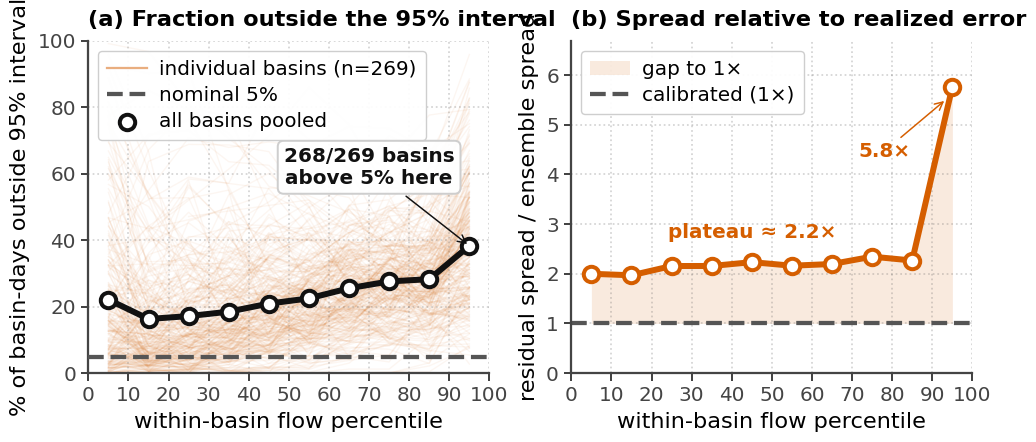

interval multiplier t(9)*sqrt((M+1)/M) = 2.3726   (naive would be 1.96)
dec        n   %outside   undersize   per-basin median%   basins>5%
  0   82,317       22.1        2.00               14.8      188/245
 10   88,420       16.3        1.97               10.9      181/254
 20   90,156       17.2        2.16               11.9      195/258
 30   96,425       18.5        2.16               15.0      226/263
 40   84,593       20.9        2.23               17.9      238/257
 50   85,847       22.5        2.16               21.7      245/261
 60   86,898       25.6        2.20               24.3      257/267
 70   87,409       27.6        2.34               27.5      263/268
 80   87,734       28.3        2.27               27.3      264/269
 90   87,930       38.3        5.76               37.7      268/269

top decile: 268/269 basins exceed the nominal 5%; pooled 38.3% outside, factor 5.76x
every decile pooled >= 16.3% outside vs 5% nominal


In [3]:
# Figure 1 (Overleaf), two panels with SEPARATE y-axes:
#   (a) count-based interval coverage, with per-basin traces (leverage-proof, moment-free)
#   (b) the undersize factor -- the width claim the common-mode argument predicts
import json
from scipy.stats import t as tdist
M = json.loads((R/"meta.json").read_text())["n_members"]      # 10; sigma_e2 is ddof=1 per contract
CORR = np.sqrt((M+1)/M)                                       # finite-ensemble spread inflation
KINT = tdist.ppf(0.975, M-1)*CORR                             # calibrated 95% PI multiplier, 2.373
cc = np.arange(5,100,10)
_r = y-mu; _s = np.sqrt(sigma_e2)
_out = np.abs(_r) > _s*KINT                                   # outside the calibrated interval

# pooled per decile, and per basin per decile (>=30 basin-days required)
cov_p = np.array([100*_out[tb&(bi==k)].mean() for k in range(10)])
und   = np.array([_r[tb&(bi==k)].std()/(np.sqrt(np.mean(sigma_e2[tb&(bi==k)]))*CORR) for k in range(10)])
COVB = np.full((y.shape[1],10), np.nan)
for j in range(y.shape[1]):
    for k in range(10):
        m = tb[:,j]&(bi[:,j]==k)
        if m.sum()>=30: COVB[j,k] = 100*_out[m,j].mean()
_ntop = int((COVB[np.isfinite(COVB[:,9]),9] > 5).sum()); _ktop = int(np.isfinite(COVB[:,9]).sum())

fig, axs = plt.subplots(1, 2, figsize=figsize(2.3), layout="constrained")
# ---- (a) coverage, count-based ----
a = axs[0]
for j in range(COVB.shape[0]):
    v = COVB[j]; g = np.isfinite(v)
    if g.sum()>1: a.plot(cc[g], v[g], "-", color=PALETTE["ens"], alpha=.055, lw=.55*S, zorder=1)
a.plot([],[],"-",color=PALETTE["ens"],alpha=.5,lw=.9*S,label=f"individual basins (n={_ktop})")
a.axhline(5.0, ls="--", lw=LW["ref"], color=PALETTE["ref"], zorder=4, label="nominal 5%")
a.plot(cc, cov_p, "-", color="#111111", lw=LW["curve"], zorder=5)
a.scatter(cc, cov_p, s=sz(38), facecolor="white", edgecolor="#111111", linewidths=1.6*S,
          zorder=6, label="all basins pooled")
a.set_ylim(0, 100); a.set_ylabel("% of basin-days outside 95% interval")
a.annotate(f"{_ntop}/{_ktop} basins\nabove 5% here", xy=(95, cov_p[9]), xytext=(70, 57),
           textcoords="data", ha="center", fontsize=FS["ann"], fontweight="bold", color="#111111",
           zorder=8, bbox=dict(boxstyle="round,pad=.3", fc="white", ec="#CCCCCC", lw=.8*S, alpha=.95),
           arrowprops=dict(arrowstyle="->", lw=LW["thin"], color="#111111"))
a.legend(loc="upper left", **LEG).set_zorder(9)
panel(a, "a", "Fraction outside the 95% interval")
# ---- (b) undersize factor: the width claim ----
b = axs[1]
b.fill_between(cc, 1.0, und, color=PALETTE["ens"], alpha=.13, lw=0, zorder=1, label="gap to 1×")
b.axhline(1.0, ls="--", lw=LW["ref"], color=PALETTE["ref"], zorder=2, label="calibrated (1×)")
b.plot(cc, und, "-", color=PALETTE["ens"], lw=LW["curve"], zorder=3)
b.scatter(cc, und, s=sz(38), facecolor="white", edgecolor=PALETTE["ens"], linewidths=1.6*S, zorder=4)
b.set_ylim(0, und.max()*1.16); b.set_ylabel("residual spread / ensemble spread")
b.text(45, 2.72, f"plateau ≈ {und[:9].mean():.1f}×", ha="center", fontsize=FS["ann"],
       fontweight="bold", color=PALETTE["ens"], zorder=6)
b.annotate(f"{und[9]:.1f}×", xy=(93.5, und[9]-.25), xytext=(78, 4.35), textcoords="data",
           ha="center", fontsize=FS["ann"], fontweight="bold", color=PALETTE["ens"], zorder=6,
           arrowprops=dict(arrowstyle="->", lw=LW["thin"], color=PALETTE["ens"]))
b.legend(loc="upper left", **LEG).set_zorder(7)
panel(b, "b", "Spread relative to realized error")
for ax in axs:
    ax.set_xlim(0,100); ax.set_xticks(range(0,101,10)); ax.set_xticklabels(range(0,101,10))
    ax.set_xlabel("within-basin flow percentile")
fig.savefig(FIG_OUT/"workshop_fig1_dispersion.png"); plt.show()

print(f"interval multiplier t({M-1})*sqrt((M+1)/M) = {KINT:.4f}   (naive would be 1.96)")
print("dec        n   %outside   undersize   per-basin median%   basins>5%")
for k in range(10):
    v = COVB[np.isfinite(COVB[:,k]),k]
    print(f"{k*10:3d} {int((tb&(bi==k)).sum()):8,d} {cov_p[k]:10.1f} {und[k]:11.2f} "
          f"{np.median(v):18.1f} {int((v>5).sum()):8d}/{len(v)}")
print(f"\ntop decile: {_ntop}/{_ktop} basins exceed the nominal 5%; pooled {cov_p[9]:.1f}% outside, "
      f"factor {und[9]:.2f}x")
print(f"every decile pooled >= {cov_p.min():.1f}% outside vs 5% nominal")

**Discussion.** Panel (a) is a count, so it is immune to the two objections that dog any moment-based statement here: it cannot be attributed to a handful of influential basin-days, and it involves no choice between SD, IQR or CRPS. **Every decile leaves at least 16% of basin-days outside a nominal-5% interval, rising to 38% at the top decile, and 268 of 269 basins exceed 5% at their own highest flows.** That is the leverage-proof form of the claim and the one closest to what a decision-maker reads off an interval.

Panel (b) is retained because the mechanism argument is a claim about **width**. Error common to all members is invisible to a between-member spread: the members share architecture, data and forcing, so error built into that shared setup is committed by all of them together, agreement stays high, and the spread cannot widen to express it. Coverage establishes that observations fall outside the stated range; only the width ratio says *how far* the range falls short — $\approx2.2\times$ across normal flows and $5.8\times$ at the extreme. Dropping (b) would leave the structural argument without its direct empirical counterpart.

The two panels also disagree in an informative way at low flow. The width ratio is $\approx2\times$ there while coverage is already 22% outside, of which **20 points are below** the interval rather than above — the scale is roughly right and the *shape* is wrong, a heavy lower tail relative to $\hat{\sigma}_e$. At the top decile the direction reverses: 34% above, 4% below, the under-predicted-peak signature. A second-moment ratio cannot see either asymmetry, which is why the count is reported alongside it.

$\hat{\sigma}^2_e$ is read as a **lower bound** on the epistemic uncertainty a well-specified ensemble should express. Aleatoric uncertainty is handled elsewhere [Klotz, Kraft]; there is no variance head here.

*Caveats.* Panel (a) assumes a Gaussian/$t$ shape for the interval — that is the practice under examination, not an endorsement, and the skew documented above is why a non-Gaussian head is the planned next step. Both panels pool basin-days within decile for the black curve; the per-basin traces in (a) and the per-basin factors reported in the supplement are the pooling-free versions. No interval is placed on either curve: under spatial and temporal autocorrelation an i.i.d. resampling interval would be anti-conservative, and the per-basin counts carry the robustness instead.

### Supplement (not the CCAI figure) — standardized-residual distribution

Retained for the HESS distributional supplement and for the per-decile exceedance numbers it prints. **Not exported and not used as the CCAI figure:** its basis $z=(y-\hat{\mu}-\overline{r}_k)/\hat{\sigma}_e$ subtracts each decile's *pooled* mean residual in mm day$^{-1}$ and then divides by a *per-cell* $\hat{\sigma}_e$ that varies by orders of magnitude. That ordering injects an offset of $|\overline{r}_k|/\hat{\sigma}_e$ per cell — which ranges from 0.30 to 2.75 across deciles, driving the apparent 80–90% dip — and at the top decile it inverts the asymmetry, halving the genuine positive tail ($q_{97.5}$ from $+19.2$ to $+10.6$) while manufacturing a $-42.7$ negative one. The spread–skill ratio above avoids all of this by never removing a mean.

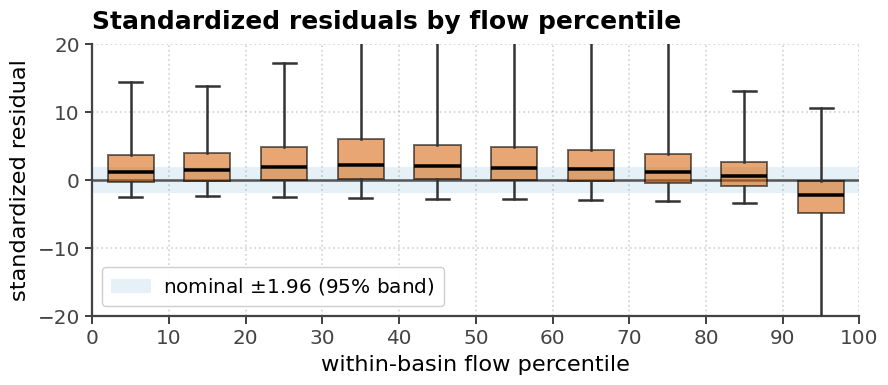

decile        n     q2.5   q97.5   % |z|>1.96
  0-10    82,317    -2.50   14.35       44.8
 10-20    88,420    -2.35   13.79       47.7
 20-30    90,156    -2.47   17.18       53.1
 30-40    96,425    -2.65   20.62       57.8
 40-50    84,593    -2.83   23.46       56.0
 50-60    85,847    -2.81   24.75       53.8
 60-70    86,898    -2.99   23.77       51.6
 70-80    87,409    -3.12   21.15       48.3
 80-90    87,734    -3.36   13.08       40.6
 90-100   87,930   -42.66   10.61       64.9
pooled: 52.0% of |z| exceeds 1.96 (nominal 5%)
y-axis clipped at +/-20; whisker extremes span -42.7 to 24.8


In [4]:
# SUPPLEMENT (not exported, not the CCAI figure): standardized-residual distribution by
# flow decile. Basis is confounded -- see the note above -- kept for the HESS distributional
# supplement and for the per-decile exceedance numbers it prints.
cc=np.arange(5,100,10); zlist=[]
for k in range(10):
    m=(bi==k)&tb; rk=(y-mu)[m]; sk=sig_e[m]; ok=sk>1e-6
    zlist.append((rk-rk.mean())[ok]/sk[ok])      # z = (y-mu)/sigma_e, per-decile mean removed
YL=20                                            # spans every upper whisker; top decile's lower one (-42.7) is cut
fig,ax=plt.subplots(figsize=figsize(2.8))
ax.axhspan(-Z,Z,color=PALETTE["indist"],alpha=.10,lw=0,zorder=0,label=r"nominal $\pm1.96$ (95% band)")
ax.axhline(0,color=PALETTE["ref"],lw=1.0*S,zorder=1)
bp=ax.boxplot(zlist,positions=cc,widths=6,whis=[2.5,97.5],showfliers=False,patch_artist=True,zorder=3)
for box in bp["boxes"]: box.set(facecolor=PALETTE["ens"],alpha=.55,edgecolor="black",linewidth=.8*S)
for med in bp["medians"]: med.set(color="black",linewidth=1.4*S)
for el in bp["whiskers"]+bp["caps"]: el.set(color="#333333",linewidth=1.0*S)
ax.set_xlabel("within-basin flow percentile")
ax.set_ylabel("standardized residual")
ax.set_title("Standardized residuals by flow percentile",loc="left")
ax.set_xlim(0,100); ax.set_ylim(-YL,YL)
# both calls are needed: boxplot leaves a FixedFormatter that mislabels the new tick positions
ax.set_xticks(range(0,101,10)); ax.set_xticklabels(range(0,101,10))
ax.legend(loc="lower left",**LEG).set_zorder(7)
plt.show()

# numbers behind the boxes (the y-axis is clipped, so read the whisker positions here)
q=np.array([[np.percentile(z,2.5),np.percentile(z,97.5)] for z in zlist])
print("decile        n     q2.5   q97.5   % |z|>1.96")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<3d} {zlist[k].size:8,d} {q[k,0]:8.2f} {q[k,1]:7.2f} {100*np.mean(np.abs(zlist[k])>Z):10.1f}")
zall=np.concatenate(zlist)
print(f"pooled: {100*np.mean(np.abs(zall)>Z):.1f}% of |z| exceeds 1.96 (nominal 5%)")
print(f"y-axis clipped at +/-{YL}; whisker extremes span {q.min():.1f} to {q.max():.1f}")

## Figure 2 (Overleaf) — Error after removal, 2021 OOD windows

Cells inside the two 2021 event windows (heat dome 06-01–07-31, AR flood 10-20–12-10; both fall inside the test split; $n=27{,}065$) are discarded largest-first under three removal rules, and the RMSE of whatever remains is plotted against the fraction discarded.

Discarding **by ensemble spread** is the rule under test. The other two bracket it: discarding **by actual error** removes the genuinely worst predictions first and is the best any rule could do — computable only after the fact; discarding **at random** is what a rule carrying no information achieves (mean of 10 permutations). **AUSE** places the spread-ranked curve between those bounds: $0$ means discarding by spread is as effective as discarding by actual error, $1$ means no better than random. Shading marks the gap between the spread-ranked and actual-error curves. The diagnostic is known as sparsification in the UQ literature.

This asks only whether $\hat{\sigma}^2_e$ carries information about *which* predictions are poor — it is not a proposal to use the spread that way. No interval is reported: see the discussion.

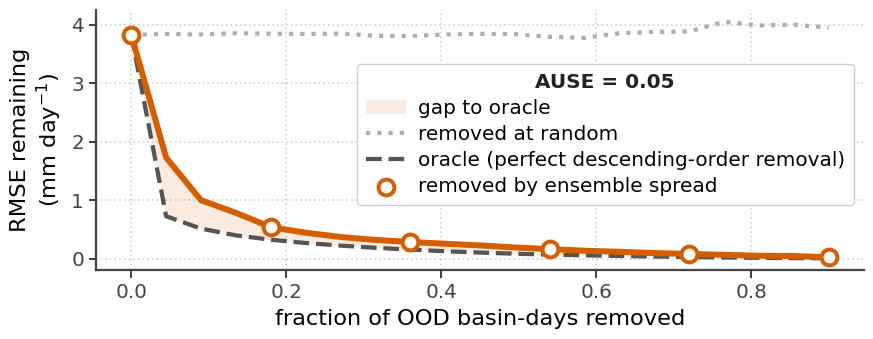

OOD cells 20,252 | in-dist cells 857,477
normalized AUSE 0.049 (0 = as good as removing by actual error, 1 = no better than random)
rank corr rho(sigma_e^2,|err|): in-dist +0.771 | OOD +0.831   (descriptive; no interval reported)


In [5]:
# Figure 2 (Overleaf): error after removal on the 2021 OOD windows (sparsification).
# Diagnostic only -- asks whether sigma_e^2 carries information about WHICH predictions are
# poor. No CI: the claim is that the spread orders error, not that two orderings differ, and
# under autocorrelation an i.i.d. interval here would be anti-conservative for no benefit.
def sparsify(se, e2, nf=21, seed=0):
    n=len(e2); fr=np.linspace(0,0.9,nf); op=np.argsort(-se); oo=np.argsort(-e2); rng=np.random.default_rng(seed)
    curve=lambda order: np.array([np.sqrt(np.mean(e2[order[int(f*n):]])) for f in fr])
    cp,co_=curve(op),curve(oo); cr=np.mean([curve(rng.permutation(n)) for _ in range(10)],axis=0)
    num=np.trapezoid(cp-co_,fr); den=np.trapezoid(cr-co_,fr)
    return fr,cp,co_,cr,(num/den if den>0 else np.nan)

se_i,e_i = sigma_e2[M_ind], err[M_ind]
se_o,e_o,e2_o = sigma_e2[M_ood], err[M_ood], err2[M_ood]
fr,cp,co_,cr,an = sparsify(se_o,e2_o)

fig, ax = plt.subplots(figsize=figsize(2.93))
ax.fill_between(fr,co_,cp,color=PALETTE["ens"],alpha=.12,lw=0,zorder=1,label="gap to oracle")
ax.plot(fr,cr,":",color=PALETTE["random"],lw=LW["ref"],label="removed at random",zorder=2)
ax.plot(fr,co_,"--",color=PALETTE["ref"],lw=LW["ref"],label="oracle (perfect descending-order removal)",zorder=3)
ax.plot(fr,cp,"-",color=PALETTE["ens"],lw=LW["curve"],zorder=4)
ax.scatter(fr[::4],cp[::4],s=sz(40),facecolor="white",edgecolor=PALETTE["ens"],
           linewidths=1.6*S,zorder=5,label="removed by ensemble spread")
ax.set_xlabel("fraction of OOD basin-days removed")
ax.set_ylabel("RMSE remaining\n"r"(mm day$^{-1}$)")
_leg=ax.legend(loc="center right", bbox_to_anchor=(1.0,.52), title=f"AUSE = {an:.2f}", **LEG)
_leg.get_title().set(fontweight="bold", fontsize=FS["ann"], color="#222222"); _leg.set_zorder(7)
fig.savefig(FIG_OUT/"workshop_fig2_shift.png"); plt.show()

print(f"OOD cells {len(e2_o):,} | in-dist cells {len(e_i):,}")
print(f"normalized AUSE {an:.3f} (0 = as good as removing by actual error, 1 = no better than random)")
print(f"rank corr rho(sigma_e^2,|err|): in-dist {spearmanr(se_i,e_i).statistic:+.3f} | "
      f"OOD {spearmanr(se_o,e_o).statistic:+.3f}   (descriptive; no interval reported)")

**Discussion.** Fig. 1 establishes that the spread is too narrow — by $\approx2.2\times$ across normal flows and $5.76\times$ at the extreme. This figure asks a separate question: under shift, does $\hat{\sigma}^2_e$ still indicate *where* the error is large? That distinguishes **confidently wrong** (orders error correctly, magnitude far too small) from **decoupled** (spread unrelated to error). The two properties are orthogonal — a signal can rank error perfectly and still be uniformly too small, and so be overconfident everywhere.

The spread-ranked curve stays close to the actual-error curve and far from random removal (**AUSE $=0.05$**), so inside the OOD windows the spread does identify which predictions are worst. The rank correlation between $\hat{\sigma}^2_e$ and $|y-\hat{\mu}|$ is $0.77$ outside the event windows and $0.83$ inside them, in the same direction. What fails under shift is the **magnitude, not the ordering** — which is what makes the Fig. 1 result *confidently wrong* rather than uninformative, and forecloses reading the spread as noise at the events.

The claim is **diagnostic**. Nothing here recommends $\hat{\sigma}_e$ as an operational triage signal; establishing that would require a decision-analytic evaluation this paper does not attempt.

*Caveats.* **No interval is placed on AUSE or on the rank correlations, deliberately.** Cells are pooled across basins and days, so under spatial and temporal autocorrelation the effective sample size is far below the cell count and an i.i.d. resampling interval would be anti-conservative. The claim here is that the spread orders error at all, not that two orderings differ by a specific amount, so the point estimates carry it and an interval would add unwarranted precision. The actual-error curve is a post-hoc bound, not an attainable baseline. The windows pool the heat dome with the AR flood, whose ~70 stations form a spatially-blocked SW-BC corridor — see the station-constraint note in `chapter3.md` (2026-07-13).

### Flow-composition control for Figure 2 (reproduces the caveat numbers)

Both $\hat{\sigma}_e$ and $|y-\hat{\mu}|$ grow with flow magnitude, so pooling deciles gives the ordering an across-regime signal that is not discrimination *within* a regime. Recomputing AUSE separately inside each within-basin flow decile of the OOD cells holds that composition fixed. Reported, not plotted — the within-stratum reference curves differ from the pooled ones, so the two cannot share a panel honestly.

In [6]:
# Flow-composition control: AUSE within each flow decile of the OOD cells.
# Reuses sparsify() from the Figure 2 cell; seeded, so the numbers are reproducible.
per=np.full(10,np.nan); ns=np.zeros(10,int)
for k in range(10):
    m=M_ood&(bi==k); ns[k]=int(m.sum())
    if ns[k]>=200: per[k]=sparsify(sigma_e2[m], err2[m])[4]
pooled=sparsify(sigma_e2[M_ood], err2[M_ood])[4]
print("decile      n    AUSE")
for k in range(10): print(f"{k*10:3d}-{k*10+10:<3d} {ns[k]:7,d} {per[k]:7.3f}")
print(f"\npooled (unstratified)          {pooled:.3f}")
print(f"within-decile, n-weighted      {np.average(per,weights=ns):.3f}   <- quoted in the paper")
print(f"within-decile, unweighted      {np.nanmean(per):.3f}")
print(f"top three deciles (70-100%)    {per[7:].min():.3f}-{per[7:].max():.3f}   <- quoted in the paper")
print(f"random ordering would give     1.000")

# Table as Appendix

decile      n    AUSE
  0-10      539   0.090
 10-20    1,131   0.091
 20-30    1,271   0.079
 30-40    2,064   0.062
 40-50    1,913   0.093
 50-60    1,795   0.061
 60-70    1,985   0.078
 70-80    2,565   0.089
 80-90    2,897   0.132
 90-100   4,092   0.149

pooled (unstratified)          0.049
within-decile, n-weighted      0.101   <- quoted in the paper
within-decile, unweighted      0.092
top three deciles (70-100%)    0.089-0.149   <- quoted in the paper
random ordering would give     1.000


### Block separation — heat dome vs AR flood (why shift is the test, not the mechanism)

The pooled "OOD" grouping mixes two physically distinct events with **different spatial extents**, and pooling them is what produced the misleading combined number.

- **Heat dome — domain-wide.** Forcing selection (Jun–Jul Tmax $z>1.5$ vs other years) retains **264 of 269** basins, matching the selection-robustness noted in `chapter3.md` (2026-07-13). Restricting changes nothing (factor 2.83 either way), so the block is left unrestricted.
- **AR flood — regional.** November 2021 was a Lower Mainland / SW-BC event; scoring it over all 269 basins dilutes it with ~200 basins in ordinary autumn conditions and *flatters* it. The block is restricted to basins **west of $-121^\circ$ (74 basins)** — a generous coastal cut, purely geographic, so it conditions on neither the forcing nor the outcome.

**Why not the forcing selector from EXP5 cell 13d here.** Applying Nov-precip $z>1.5$ domain-wide selects 88 basins, but only 3 lie west of $-123^\circ$ and the set is dominated by interior Columbia/Kootenay and Athabasca basins — median longitude $-116.5^\circ$, *east* of the domain median. Standardizing precipitation against each basin's own November climatology favours dry interior basins where any rain is anomalous and penalises coastal basins that are wet and variable every November. Within the coastal block the median $z$ is only 0.50. That selector remains valid for its original purpose (avoiding outcome-conditioning in the shrinkage slope) but is **not** an event-membership filter.

**Caveat on the definition.** A longitude threshold is a crude proxy for the SW-BC corridor. `chapter3.md` §5 (2D) refers to a citation-grounded corridor of ~31 basins (22 precip-confirmed); if that list exists it should supersede this cut, and the definition belongs in the methods log before it is used in the paper. The sensitivity ladder printed below exists so the choice is auditable — every tighter definition makes the AR block *worse*, so the generous cut is the conservative one.

Two results follow, and together they are why the framing moved from *shift as mechanism* to *shift as test*: at **matched flow percentile** the heat dome is *better* calibrated than in-distribution (top decile 3.23 vs 5.66) while the AR flood is worse (10.16). One event degrades, one does not. Note also `chapter3.md` §7: the AR flood's most credible cause is orographic precipitation under-capture, i.e. a **forcing** error shared by every member — still common-mode, but originating upstream of the model, which is a weaker basis for a claim about the model's own epistemic humility.

This does not contradict the heat-dome mean regression recorded in `chapter3.md` ($\hat{\mu}/\mathrm{obs}\approx0.81$): that is a statement about **bias**, which the residual SD in this factor removes by construction.

In [7]:
# Block separation: per-decile undersize factor, in-distribution vs each 2021 event.
# Heat dome = domain-wide (forcing-selection retains 264/269, so no restriction).
# AR flood  = regional, restricted to basins west of -121 deg (74 basins); see note above.
from src.config import PROCESSED_DATA_DIR
# AR_WEST, HD_DAYS, AR_DAYS and lon all come from the load cell -- one definition, reused.
HD, AR = HD_DAYS, AR_DAYS
B = {"in-distribution": M_ind,
     "heat dome (269)": (test&HD)[:,None]&valid,
     "AR flood (74 W)": ((test&AR)[:,None]&valid) & AR_WEST[None,:]}
def fac(m, minn=30):
    if m.sum()<minn: return (int(m.sum()), np.nan, np.nan)
    r=(y-mu)[m]; s=np.sqrt(sigma_e2[m])*CORR
    return (int(m.sum()), r.std(), r.std()/np.sqrt(np.mean(s**2)))

print("per-decile undersize factor by block      (n / resid SD / factor)")
print("dec |   in-distribution    |   heat dome (all 269) |   AR flood (74 west)")
for k in range(10):
    row=f"{k*10:3d} |"
    for nm,m in B.items():
        n,sd,f=fac(m&(bi==k))
        row += f" {n:7,d} {sd:6.2f} {f:6.2f} |" if np.isfinite(f) else f" {n:7,d}   (n<30)   |"
    print(row)
print("-"*70)
for nm,m in B.items():
    n,sd,f=fac(m); print(f"{nm:16s} n={n:7,d}  basins={int((m.sum(axis=0)>0).sum()):3d}"
                         f"  resid SD={sd:6.3f}  factor={f:5.2f}")
print("\nmatched-flow comparison (top decile): in-dist "
      f"{fac(B['in-distribution']&(bi==9))[2]:.2f}  |  heat dome {fac(B['heat dome (269)']&(bi==9))[2]:.2f}"
      f"  |  AR flood {fac(B['AR flood (74 W)']&(bi==9))[2]:.2f}")
print("-> heat dome is BETTER calibrated than in-distribution; only the AR flood is worse.")

# sensitivity ladder for the AR definition: every tighter cut makes it worse, so the
# generous geographic cut is the conservative choice.
_pf = PROCESSED_DATA_DIR/"climate"/"daily_precipitation.csv"
print("\nAR definition sensitivity (top-decile factor):")
lad = [("all 269 basins (diluted)", np.isfinite(lon)), ("west of -120", lon<-120),
       ("west of -121  [canonical]", lon<-121), ("west of -122", lon<-122), ("west of -123", lon<-123)]
if _pf.exists():
    _p = pd.read_csv(_pf, index_col=0, parse_dates=True).reindex(index=dates, columns=stations)
    _s = (dates.month==11); _w = _p[_s].groupby(dates.year[_s]).max(); _o = _w.drop(index=2021)
    zP = ((_w.loc[2021]-_o.mean())/_o.std()).values
    lad += [("west -121 & Nov P z>1.0", (lon<-121)&(zP>1.0)),
            ("west -121 & Nov P z>1.5", (lon<-121)&(zP>1.5))]
for nm,g in lad:
    g=g&np.isfinite(lon); m=((test&AR)[:,None]&valid)&g[None,:]
    n,_,f=fac(m); nt,_,ft=fac(m&(bi==9))
    print(f"  {nm:26s} basins={int(g.sum()):3d}  n={n:6,d}  overall="
          + (f"{f:5.2f}" if np.isfinite(f) else "    -")
          + f"  top decile=" + (f"{ft:6.2f} (n={nt:,})" if np.isfinite(ft) else "   (n<30)"))

per-decile undersize factor by block      (n / resid SD / factor)
dec |   in-distribution    |   heat dome (all 269) |   AR flood (74 west)
  0 |  81,778   0.23   2.00 |     500   0.11   1.53 |      39   0.03   1.00 |
 10 |  87,289   0.28   1.97 |   1,033   0.13   1.50 |      98   0.14   1.61 |
 20 |  88,885   0.41   2.16 |   1,100   0.19   1.77 |     171   0.21   1.15 |
 30 |  94,361   0.51   2.16 |   1,321   0.25   1.72 |     743   0.65   1.99 |
 40 |  82,680   0.71   2.24 |     897   0.31   1.82 |   1,016   0.81   2.07 |
 50 |  84,052   0.82   2.16 |   1,163   0.44   1.75 |     632   1.36   2.07 |
 60 |  84,913   1.03   2.20 |   1,643   0.55   1.43 |     342   2.01   2.04 |
 70 |  84,844   1.32   2.35 |   2,323   0.66   1.41 |     242   3.72   2.63 |
 80 |  84,837   1.63   2.27 |   2,686   0.88   1.34 |     211   5.25   2.60 |
 90 |  83,838   5.47   5.68 |   3,743   3.24   3.23 |     349  23.77  10.16 |
----------------------------------------------------------------------
in-distri

### Alternate Figure 2 — regime comparison (in-distribution vs 2021 events)

Same sparsification diagnostic as Figure 2, run separately on the two disjoint halves of the test split: cells outside the 2021 event windows ($n=850{,}664$) and cells inside them ($n=27{,}065$). The question is whether the spread's ability to *order* error degrades under shift.

Panels carry **independent $y$-scales** — the event windows start from a much larger RMSE (3.46 vs 1.95 mm day$^{-1}$), so a shared axis would flatten the in-distribution panel. The comparison is therefore made through the two AUSE values, not by eye across panels. Exported separately as `workshop_fig2_regimes.png`; the single-panel Figure 2 remains the primary.

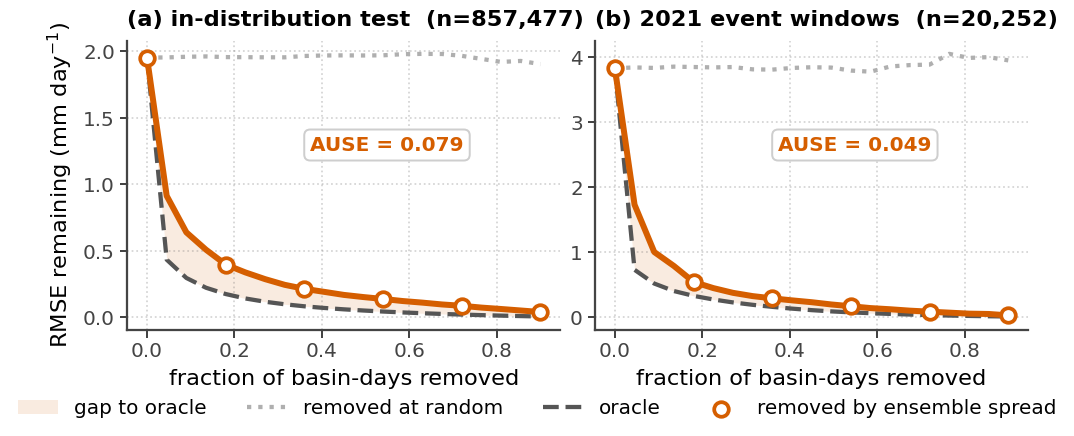

in-distribution  n=857,477  RMSE(f=0)=1.954  AUSE=0.079
2021 windows     n=20,252  RMSE(f=0)=3.827  AUSE=0.049
ordering skill does not degrade under shift (AUSE is lower at the events);
random ordering would give 1.000 in both regimes.


In [8]:
# Alternate Figure 2: sparsification run separately in-distribution vs OOD windows.
# Reuses sparsify() from the Figure 2 cell. AUSE is computed, never hardcoded, so this
# figure and the primary Figure 2 cannot drift apart on the shared OOD number.
fr_i,cp_i,co_i,cr_i,an_i = sparsify(sigma_e2[M_ind], err2[M_ind])
fr_o,cp_o,co_o,cr_o,an_o = sparsify(sigma_e2[M_ood], err2[M_ood])

fig, axs = plt.subplots(1, 2, figsize=figsize(2.3), layout="constrained")
panels = [(cp_i,co_i,cr_i,an_i,"in-distribution test",int(M_ind.sum())),
          (cp_o,co_o,cr_o,an_o,"2021 event windows",  int(M_ood.sum()))]
for k,(a,(cp,co,cr,au,ttl,nn)) in enumerate(zip(axs,panels)):
    a.fill_between(fr_i,co,cp,color=PALETTE["ens"],alpha=.12,lw=0,zorder=1,label="gap to oracle")
    a.plot(fr_i,cr,":",color=PALETTE["random"],lw=LW["ref"],zorder=2,label="removed at random")
    a.plot(fr_i,co,"--",color=PALETTE["ref"],lw=LW["ref"],zorder=3,label="oracle")
    a.plot(fr_i,cp,"-",color=PALETTE["ens"],lw=LW["curve"],zorder=4)
    a.scatter(fr_i[::4],cp[::4],s=sz(34),facecolor="white",edgecolor=PALETTE["ens"],
              linewidths=1.5*S,zorder=5,label="removed by ensemble spread")
    panel(a,"ab"[k],f"{ttl}  (n={nn:,})")
    a.set_xlabel("fraction of basin-days removed")
    a.annotate(f"AUSE = {au:.3f}",xy=(.60,.62),xycoords="axes fraction",ha="center",
               fontsize=FS["ann"],fontweight="bold",color=PALETTE["ens"],zorder=6,
               bbox=dict(boxstyle="round,pad=.3",fc="white",ec="#CCCCCC",lw=.8*S,alpha=.95))
axs[0].set_ylabel(r"RMSE remaining (mm day$^{-1}$)")
h,l = axs[0].get_legend_handles_labels()
fig.legend(h,l,loc="outside lower center",ncol=4,fontsize=FS["leg"],frameon=False)
fig.savefig(FIG_OUT/"workshop_fig2_regimes.png"); plt.show()

print(f"in-distribution  n={int(M_ind.sum()):,}  RMSE(f=0)={cp_i[0]:.3f}  AUSE={an_i:.3f}")
print(f"2021 windows     n={int(M_ood.sum()):,}  RMSE(f=0)={cp_o[0]:.3f}  AUSE={an_o:.3f}")
print("ordering skill does not degrade under shift (AUSE is lower at the events);")
print("random ordering would give 1.000 in both regimes.")

### Reserve check — CRPS (not a paper figure)

Held in reserve in case a probabilistic-ML reviewer asks for a proper scoring rule rather than AUSE and the spread–skill ratio. Treats the ensemble as $\mathcal{N}(\hat{\mu},\,(c\,\hat{\sigma}_e)^2)$ and asks which spread inflation $c$ *minimises* CRPS in each flow decile — an independent estimate of how far the spread is from the scale a proper score would prefer. A calibrated spread would put $c^\star=1$.

CRPS uses the closed form $\mathrm{CRPS}(\mathcal{N}(\mu,\sigma),y)=\sigma\left[z(2\Phi(z)-1)+2\phi(z)-\pi^{-1/2}\right]$, $z=(y-\hat{\mu})/\sigma$, verified against numerical integration of $\int(F-\mathbb{1}\{x\ge y\})^2dx$ to $10^{-9}$ at $z=0$. $\hat{\sigma}_e$ carries the same $\sqrt{(M{+}1)/M}$ correction as Figure 1, so $c$ is measured on the same scale as that figure's undersize factor. **This is the Gaussian-family CRPS, not the empirical ensemble CRPS** — the latter needs the 10 member series, which are not in the `results_MVE` contract (only aggregate moments), so computing it would mean re-deriving the index alignment.

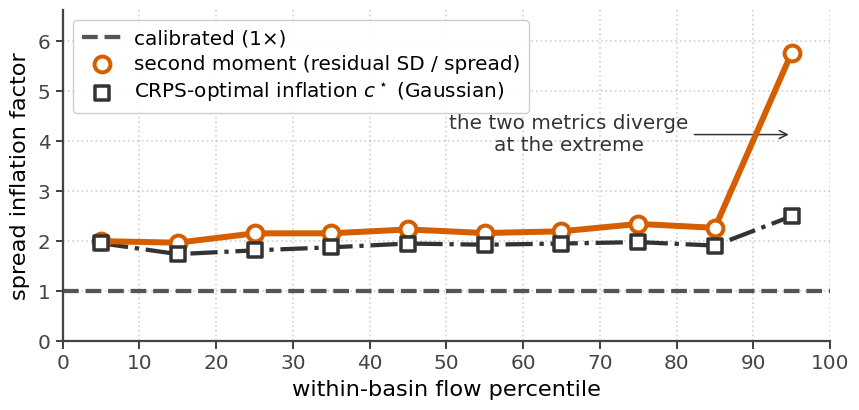

decile   c* (CRPS)   undersize (SD)   CRPS penalty at c=1
  0-10       1.96           2.00                8.8%
 10-20       1.74           1.97                5.9%
 20-30       1.82           2.16                6.4%
 30-40       1.88           2.16                6.9%
 40-50       1.95           2.23                7.5%
 50-60       1.93           2.16                7.1%
 60-70       1.95           2.20                7.0%
 70-80       1.98           2.34                6.8%
 80-90       1.91           2.27                5.8%
 90-100      2.50           5.76                6.1%

plateau (0-90%): c* mean 1.90  vs  SD-based 2.16   -> AGREE (~2x)
top decile:      c*      2.50  vs  SD-based 5.76   -> DIVERGE (2.3x apart)
CRPS penalty for using the raw spread (c=1): 5.8-8.8% across deciles


In [9]:
# RESERVE (exported but not a paper figure): CRPS-optimal spread inflation vs the
# second-moment undersize factor of Figure 1. Shows where the two metrics agree and diverge.
from scipy.stats import norm
SQPI = 1/np.sqrt(np.pi)
def mean_crps(r, s):
    z = r/s
    return np.mean(s*(z*(2*norm.cdf(z)-1) + 2*norm.pdf(z) - SQPI))
def c_star(r, s):
    g = np.exp(np.linspace(np.log(0.4), np.log(14), 60))
    v = np.array([mean_crps(r, c*s) for c in g]); k = int(v.argmin())
    g2 = np.exp(np.linspace(np.log(g[max(k-1,0)]), np.log(g[min(k+1,59)]), 41))
    v2 = np.array([mean_crps(r, c*s) for c in g2]); k2 = int(v2.argmin())
    return g2[k2], v2[k2], mean_crps(r, s)

cc = np.arange(5,100,10); cst = np.empty(10); und = np.empty(10); pen = np.empty(10)
for k in range(10):
    m = (bi==k)&tb; r = (y-mu)[m]; s = np.sqrt(sigma_e2[m])*CORR
    cst[k], vmin, v1 = c_star(r, s)
    und[k] = r.std()/np.sqrt(np.mean(s**2)); pen[k] = 100*(v1/vmin - 1)

fig, ax = plt.subplots(figsize=figsize(2.3))
ax.axhline(1.0, ls="--", lw=LW["ref"], color=PALETTE["ref"], zorder=2, label="calibrated (1×)")
ax.plot(cc, und, "-", color=PALETTE["ens"], lw=LW["curve"], zorder=4)
ax.scatter(cc, und, s=sz(40), facecolor="white", edgecolor=PALETTE["ens"], linewidths=1.6*S,
           zorder=5, label="second moment (residual SD / spread)")
ax.plot(cc, cst, "-.", color="#333333", lw=LW["ref"], zorder=3)
ax.scatter(cc, cst, s=sz(34), marker="s", facecolor="white", edgecolor="#333333",
           linewidths=1.4*S, zorder=5, label="CRPS-optimal inflation $c^\\star$ (Gaussian)")
ax.set_xlabel("within-basin flow percentile")
ax.set_ylabel("spread inflation factor")
ax.set_xlim(0,100); ax.set_ylim(0, max(und.max(), cst.max())*1.15)
ax.set_xticks(range(0,101,10)); ax.set_xticklabels(range(0,101,10))
ax.annotate("the two metrics diverge\nat the extreme", xy=(95, (und[9]+cst[9])/2),
            xytext=(66, (und[9]+cst[9])/2), textcoords="data", ha="center", va="center",
            fontsize=FS["ann"], color="#333333",
            arrowprops=dict(arrowstyle="->", lw=LW["thin"], color="#333333"))
ax.legend(loc="upper left", **LEG).set_zorder(7)
fig.savefig(FIG_OUT/"workshop_crps_check.png"); plt.show()

print("decile   c* (CRPS)   undersize (SD)   CRPS penalty at c=1")
for k in range(10):
    print(f"{k*10:3d}-{k*10+10:<3d} {cst[k]:9.2f} {und[k]:14.2f} {pen[k]:18.1f}%")
print(f"\nplateau (0-90%): c* mean {cst[:9].mean():.2f}  vs  SD-based {und[:9].mean():.2f}   -> AGREE (~2x)")
print(f"top decile:      c*      {cst[9]:.2f}  vs  SD-based {und[9]:.2f}   -> DIVERGE ({und[9]/cst[9]:.1f}x apart)")
print(f"CRPS penalty for using the raw spread (c=1): {pen.min():.1f}-{pen.max():.1f}% across deciles")